<a href="https://colab.research.google.com/github/aylinnyma/Scientific_Programming/blob/main/RegressionAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EDA PROJECT: KING COUNTY DATASET ANALYSIS 🏠**

**Team 3:** Dina, Mourad, and Aylin

## **Library Imports 📚**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, roc_curve, auc, classification_report


In [2]:
sns.set(style="whitegrid", context="notebook")
%matplotlib inline

## **Load Dataset 📑**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
path = "/content/drive/MyDrive/DHBW/Scientific Programming Lab/EDA_Project/KC_housing_data.csv"

df = pd.read_csv(path)

Confirm if dataset was succesfully loaded

In [5]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


## **BASIC EDA**

In [6]:
df.shape

(4600, 18)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [8]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


**First Impressions:**

* It contains 4600 rows and 18 columns
* All cells contain valid values (no presence of non-null values)
* It still needs some second-review on the price, bedrooms and bathrooms
* The types different datatypes in this datased are float, int, and object
* The information shown from the description of the database already provides us with useful information we will need in further analysis

In [9]:
# drop rows without price, 0 bedrooms and 0 bathrooms since they are not relevant
df = df.drop(df[df['price'] == 0].index)
df = df.drop(df[df['bedrooms'] == 0].index)
df = df.drop(df[df['bathrooms'] == 0].index)

In [10]:
features = [
    "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors",
    "waterfront", "view", "condition", "sqft_above",
    "sqft_basement", "yr_built", "yr_renovated"
]

# check they are correct
set(features) - set(df.columns)

set()

Drop rows with missing values in these key columns

In [11]:
data = df[features + ["price"]].dropna()
data.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price
0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,313000.0
1,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,2384000.0
2,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,342000.0
3,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,420000.0
4,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,550000.0


In [12]:
data.describe()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price
count,4549.000000,4549.000000,4549.000000,4.549000e+03,4549.000000,4549.000000,4549.000000,4549.000000,4549.000000,4549.000000,4549.000000,4549.000000,4.549000e+03
mean,3.396131,2.155968,2131.578809,1.483460e+04,1.511651,0.006595,0.234337,3.449549,1821.291932,310.286876,1970.787206,808.036272,5.576257e+05
std,0.901988,0.775205,955.234941,3.597114e+04,0.537794,0.080949,0.765085,0.675242,853.292493,462.043404,29.763891,979.313181,5.638915e+05
min,1.000000,0.750000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000,7.800000e+03
25%,3.000000,1.750000,1460.000000,5.000000e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000,3.261000e+05
50%,3.000000,2.250000,1970.000000,7.680000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000,4.650000e+05
75%,4.000000,2.500000,2610.000000,1.097000e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,600.000000,1997.000000,1999.000000,6.575000e+05
max,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000,2.659000e+07


## **Task 1:**

Visualize price vs key features relationships

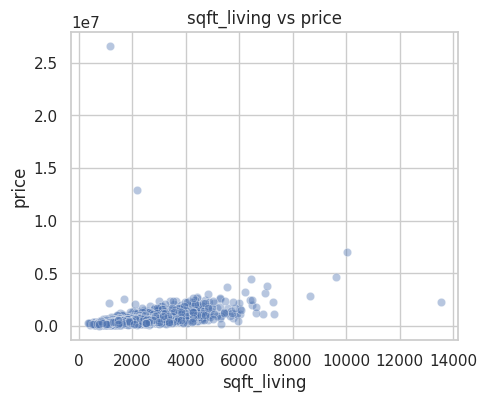

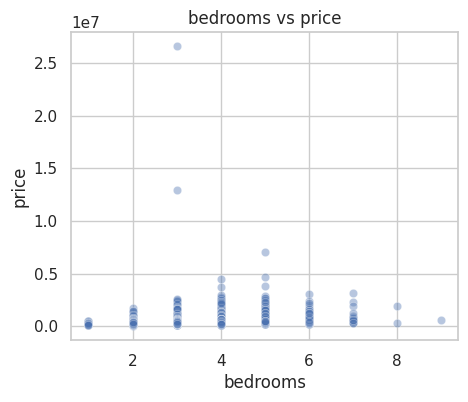

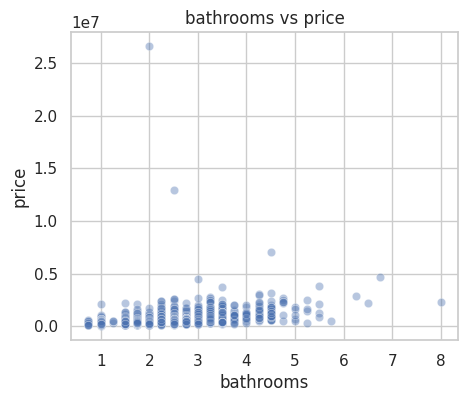

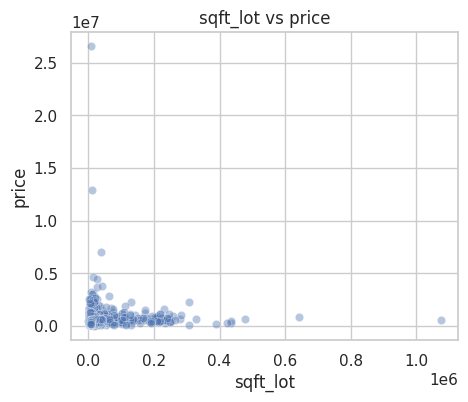

In [13]:
features_to_plot = ["sqft_living", "bedrooms", "bathrooms", "sqft_lot"]

for col in features_to_plot:
    plt.figure(figsize=(5, 4))
    sns.scatterplot(data=data, x=col, y="price", alpha=0.4)
    plt.title(f"{col} vs price")
    plt.show()

check correlation

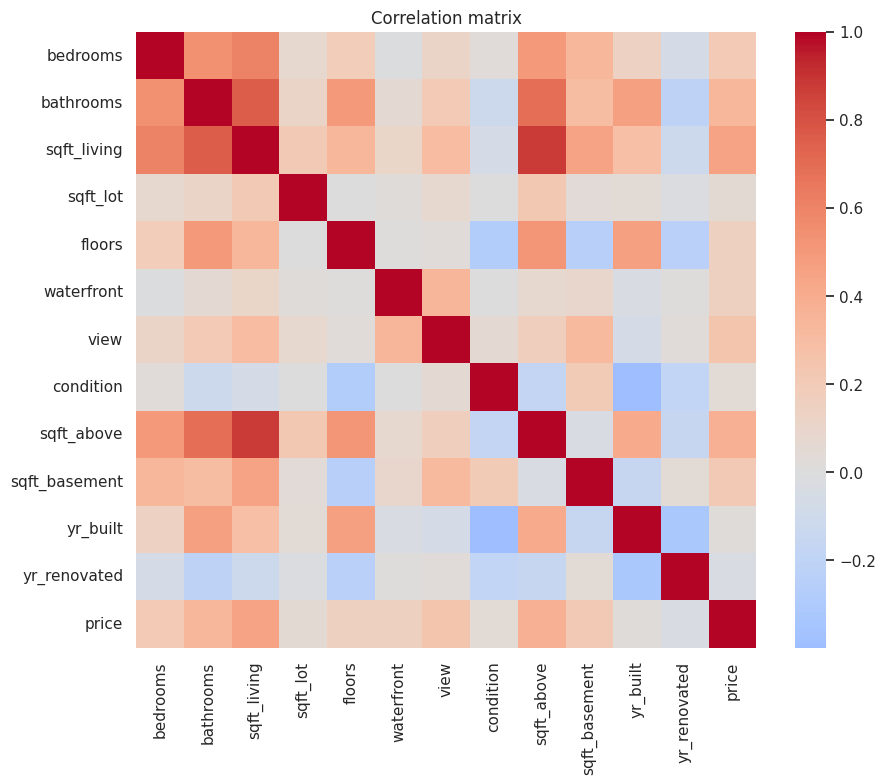

In [14]:
plt.figure(figsize=(10, 8))
corr = data[features + ["price"]].corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

**Linear regression**

### Model A (keeping outliers)

For this first model, we kept our clean dataset as it is to analyse

In [15]:
# define x and y
X_a = data[features]
y_a = data["price"]

# define train data and test data
X_a_train_lr, X_a_test_lr, y_a_train_lr, y_a_test_lr = train_test_split(
    X_a, y_a, test_size=0.2, random_state=42
)

# linear regression model
lin_reg = LinearRegression()
lin_reg.fit(X_a_train_lr, y_a_train_lr)

LinearRegression()

In [16]:
coeff_df = pd.DataFrame({
    "feature": features,
    "coefficient": lin_reg.coef_
})
coeff_df

,feature,coefficient
0,bedrooms,-60438.769733
1,bathrooms,71694.497232
2,sqft_living,165.401694
3,sqft_lot,-0.624527
4,floors,29920.435408
5,waterfront,434854.891218
6,view,50312.433931
7,condition,33212.462600
8,sqft_above,102.274833
9,sqft_basement,63.126860


The coefficient helps us compare how much the price changes when each variable is increased per one unit. By using this approach we can already see we have very big coefficients, which is not ideal for a good analysis

In [17]:
# predict on test set and compute MSE
y_a_pred_lr = lin_reg.predict(X_a_test_lr)
mse = mean_squared_error(y_a_test_lr, y_a_pred_lr)
rmse = np.sqrt(mse)
mse, rmse

(62709493058.80412, np.float64(250418.6356060669))

MSE is the average squared difference between true and predicted prices. RMSE is in the same units as price.

We can see that by using this modeling, our RMSE is by $250,418.63 off in the prediction of the prices, which is a very high amount, this already tells us this modeling can be polished.

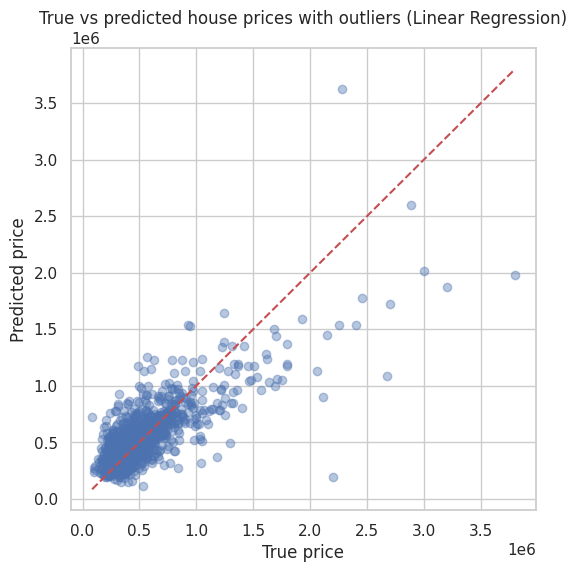

In [18]:
# plot true vs predicted prices

plt.figure(figsize=(6, 6))
plt.scatter(y_a_test_lr, y_a_pred_lr, alpha=0.4)
plt.xlabel("True price")
plt.ylabel("Predicted price")
plt.title("True vs predicted house prices with outliers (Linear Regression)")
# Add y = x reference line
lims = [
    min(y_a_test_lr.min(), y_a_pred_lr.min()),
    max(y_a_test_lr.max(), y_a_pred_lr.max())
]
plt.plot(lims, lims, 'r--')
plt.show()

As we were thinking, there is no consistency in this model, the outliers are way out of range and this is a model we cannot use to predict accurately

### Model B (without outliers)

This time we will try a similar approach, but instead we will try to get rid of the noise. The very extreme prices that make our model right-skewed.

First we start by using only the data between the first and third quantile, to exclude any outliers

In [19]:
print(f"\nPrice distribution BEFORE outlier removal:")
print(df["price"].describe().apply(lambda x: f"{x:,.0f}"))

Q1  = df["price"].quantile(0.25)
Q3  = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nIQR Bounds:")
print(f"  Lower: ${lower_bound:,.0f}")
print(f"  Upper: ${upper_bound:,.0f}")


Price distribution BEFORE outlier removal:
count         4,549
mean        557,626
std         563,891
min           7,800
25%         326,100
50%         465,000
75%         657,500
max      26,590,000
Name: price, dtype: object

IQR Bounds:
  Lower: $-171,000
  Upper: $1,154,600


In [20]:
# Filter data inside bounds
df_modelB = data[(data['price'] <= upper_bound)]

# Verify
print(f"Before: {len(df)} entries, After: {len(df_modelB)} entries")

Before: 4549 entries, After: 4310 entries


Now, with this new data, we'll train our model

In [21]:
# define x and y
X_b = df_modelB[features]
y_b = df_modelB["price"]

# define train data and test data
X_b_train_lr, X_b_test_lr, y_b_train_lr, y_b_test_lr = train_test_split(
    X_b, y_b, test_size=0.2, random_state=42
)

# linear regression model
lin_reg = LinearRegression()
lin_reg.fit(X_b_train_lr, y_b_train_lr)

coeff_df = pd.DataFrame({
    "feature": features,
    "coefficient": lin_reg.coef_
})
coeff_df

,feature,coefficient
0,bedrooms,-30275.639664
1,bathrooms,46970.199790
2,sqft_living,107.732295
3,sqft_lot,-0.197557
4,floors,54366.292964
5,waterfront,48233.637350
6,view,27869.401158
7,condition,20506.267224
8,sqft_above,63.870383
9,sqft_basement,43.861912


In [22]:
# predict on test set and compute MSE
y_b_pred_lr = lin_reg.predict(X_b_test_lr)
mse = mean_squared_error(y_b_test_lr, y_b_pred_lr)
rmse = np.sqrt(mse)
mse, rmse

(25510322606.39882, np.float64(159719.51229076184))

Our coefficients are already lower, which is good, and our RMSE is still off for $159,719.51. Which is already better, but it can be further optimized

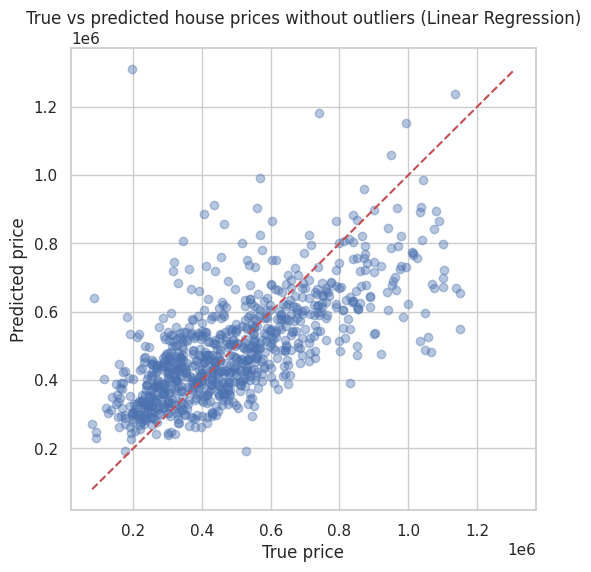

In [23]:
# plot true vs predicted prices

plt.figure(figsize=(6, 6))
plt.scatter(y_b_test_lr, y_b_pred_lr, alpha=0.4)
plt.xlabel("True price")
plt.ylabel("Predicted price")
plt.title("True vs predicted house prices without outliers (Linear Regression)")
# Add y = x reference line
lims = [
    min(y_b_test_lr.min(), y_b_pred_lr.min()),
    max(y_b_test_lr.max(), y_b_pred_lr.max())
]
plt.plot(lims, lims, 'r--')
plt.show()

This chart proves our assumptions, the prediction line looks more accurate. But like we've mentioned before, there is still room for improvement.

### Model C (using log(price))

This time we tried using the log(price) approach, but including the outliers, to analyse wether this would solve the problem of the very high prices in our dataset. Ideally, we would like to include them, since without them our model would not be able to predict the price of a house that has more high-end or luxurious characteristics.

In [24]:
# define x and y
X_c = df_modelB[features]  # df withouth outliers
y_c = np.log(df_modelB["price"])  # apply log to price

# define train data and test data
X_c_train_lr, X_c_test_lr, y_c_train_lr, y_c_test_lr = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42
)

# linear regression model
lin_reg_c = LinearRegression()
lin_reg_c.fit(X_c_train_lr, y_c_train_lr)

coeff_df_c = pd.DataFrame({
    "feature": features,
    "coefficient": lin_reg_c.coef_
})
coeff_df_c

,feature,coefficient
0,bedrooms,-5.762647e-02
1,bathrooms,1.184544e-01
2,sqft_living,2.135951e-04
3,sqft_lot,-4.415007e-07
4,floors,1.489260e-01
5,waterfront,9.908589e-02
6,view,4.656566e-02
7,condition,5.996599e-02
8,sqft_above,1.048050e-04
9,sqft_basement,1.087901e-04


In [25]:
# predict on test set and compute MSE
y_c_pred_lr = lin_reg_c.predict(X_c_test_lr)
mse_c = mean_squared_error(y_c_test_lr, y_c_pred_lr)
rmse_c = np.sqrt(mse_c)
mse_c, rmse_c

(0.12547198058744852, np.float64(0.35422024305147853))

Our coefficients are now more readable, in a percentage form, and our RMSE looks quite good.

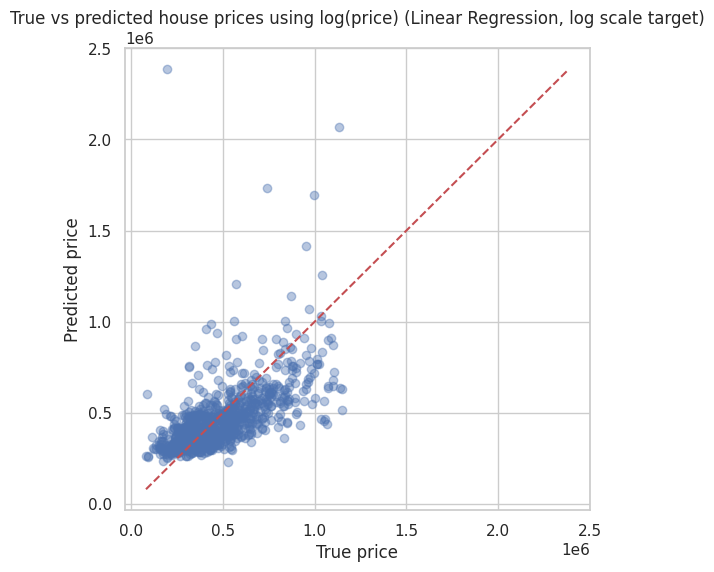

In [26]:
# transform predictions back to original scale
y_c_pred_original = np.exp(y_c_pred_lr)
y_c_test_original = np.exp(y_c_test_lr)

# plot true vs predicted prices in original scale
plt.figure(figsize=(6, 6))
plt.scatter(y_c_test_original, y_c_pred_original, alpha=0.4)
plt.xlabel("True price")
plt.ylabel("Predicted price")
plt.title("True vs predicted house prices using log(price) (Linear Regression, log scale target)")
# Add y = x reference line
lims = [
    min(y_c_test_original.min(), y_c_pred_original.min()),
    max(y_c_test_original.max(), y_c_pred_original.max())
]
plt.plot(lims, lims, 'r--')
plt.show()

Even though this solved the right-skewed model problem, we still have some outliers that are causing our model problems.

### Final Modeling

For our final modeling, we decided to combine model B and C, by getting rid of the noise and transforming our prices using log, we can have a better prediction model. This is the dataset from model B we will be using:

In [27]:
df_modelB["price"].describe().apply(lambda x: f"{x:,.0f}")

,price
count,"4,310"
mean,"487,316"
std,"215,486"
min,"7,800"
25%,"320,000"
50%,"450,000"
75%,"615,000"
max,"1,150,000"


In [28]:
# we get rid of houses that are causing a lot of noise
indexes_to_delete = [4398, 634, 853, 539, 502, 475, 491]
df = df.drop(indexes_to_delete, axis=0, errors='ignore')

# get IQR
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

# model B without noise and outliers from IQR
df_modelB = df[df['price'] <= upper_bound]

# train with logarithm (model C)
X = df_modelB[features]
y_log = np.log(df_modelB["price"])

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train_log)

# linear regression
y_pred_log = model.predict(X_test)

# to compute the real error in dlls $
y_pred_real = np.exp(y_pred_log)
y_test_real = np.exp(y_test_log)

rmse_final = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
print(f"Final average error: ${rmse_final:,.2f}")

Final average error: $163,755.59


Our very final average error is not as low as we would like it to be, but at least our model is considering high-end houses as well which makes it more robust at the end of the day

In [29]:
# make sure of correct indexing
results_df = X_c_test_lr.copy()
results_df = results_df.reset_index(drop=True)
y_test_real = y_test_real.reset_index(drop=True)
y_pred_real = pd.Series(y_pred_real).reset_index(drop=True)

# add
results_df['price_real'] = y_test_real
results_df['price_pred'] = y_pred_real
results_df['abs_error'] = abs(results_df['price_real'] - results_df['price_pred'])

# order by error
top_outliers = results_df.sort_values(by='abs_error', ascending=False).head(5)
money_cols = ['price_real', 'price_pred', 'abs_error']

formatted_outliers = top_outliers.copy()
for col in money_cols:
    formatted_outliers[col] = formatted_outliers[col].map('${:,.2f}'.format)

print("Top 5 houses with most prediction error:")
formatted_outliers

Top 5 houses with most prediction error:


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price_real,price_pred,abs_error
328,3.0,1.75,2450,2691,2.0,0,0,3,1750,700,1915,0,"$430,000.00","$1,109,257.78","$679,257.78"
295,3.0,1.00,1050,5664,1.0,0,0,4,910,140,1947,1988,"$1,087,500.00","$461,754.27","$625,745.73"
449,2.0,1.00,770,7906,1.0,0,0,4,770,0,1948,0,"$1,058,000.00","$462,092.66","$595,907.34"
227,5.0,4.50,4850,40902,2.0,0,0,3,4850,0,2001,0,"$1,050,000.00","$459,579.54","$590,420.46"
176,3.0,1.00,1500,13500,1.0,0,0,4,1500,0,1968,0,"$955,000.00","$1,536,308.42","$581,308.42"


In [30]:
overestimated = results_df[results_df['price_pred'] > results_df['price_real'] * 2].sort_values(by='abs_error', ascending=False)

print("\nHouses where the model predicted more than double of the price:")

money_cols = ['price_real', 'price_pred', 'abs_error']

formatted_overestimated = overestimated.copy()
for col in money_cols:
    formatted_overestimated[col] = formatted_overestimated[col].map('${:,.2f}'.format)

formatted_overestimated


Houses where the model predicted more than double of the price:


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price_real,price_pred,abs_error
328,3.0,1.75,2450,2691,2.0,0,0,3,1750,700,1915,0,"$430,000.00","$1,109,257.78","$679,257.78"
506,2.0,1.00,770,4000,1.0,0,0,5,770,0,1924,1956,"$188,000.00","$653,026.50","$465,026.50"
272,2.0,1.25,860,1277,2.0,0,0,3,860,0,2007,0,"$297,857.14","$658,846.63","$360,989.49"
706,1.0,0.75,370,1801,1.0,0,0,5,370,0,1923,0,"$180,785.71","$526,704.47","$345,918.76"
825,3.0,2.50,1650,14054,1.0,0,0,4,1130,520,1986,0,"$293,000.00","$594,973.36","$301,973.36"
734,3.0,2.25,1200,1400,3.0,0,0,3,1200,0,2005,0,"$234,000.00","$521,870.76","$287,870.76"
566,4.0,2.50,2440,11005,2.0,0,0,3,2440,0,1994,0,"$132,250.00","$417,332.86","$285,082.86"
500,3.0,1.00,1340,15600,1.0,0,0,4,1340,0,1978,2000,"$254,500.00","$528,332.51","$273,832.51"
775,3.0,2.50,1680,11193,2.0,0,0,3,1680,0,1984,0,"$107,500.00","$363,714.36","$256,214.36"
426,1.0,1.00,800,16306,1.0,0,0,2,680,120,1931,0,"$215,000.00","$455,648.54","$240,648.54"


We also identified the houses that were off the prediction by a lot, to identify what would be the reason. We believe some of them were sold way below for their price just by taking into consideration their characteristics alone. The actual reasons behind this are beyond our scope, but we leave this on the table to take it into consideration for further analysis

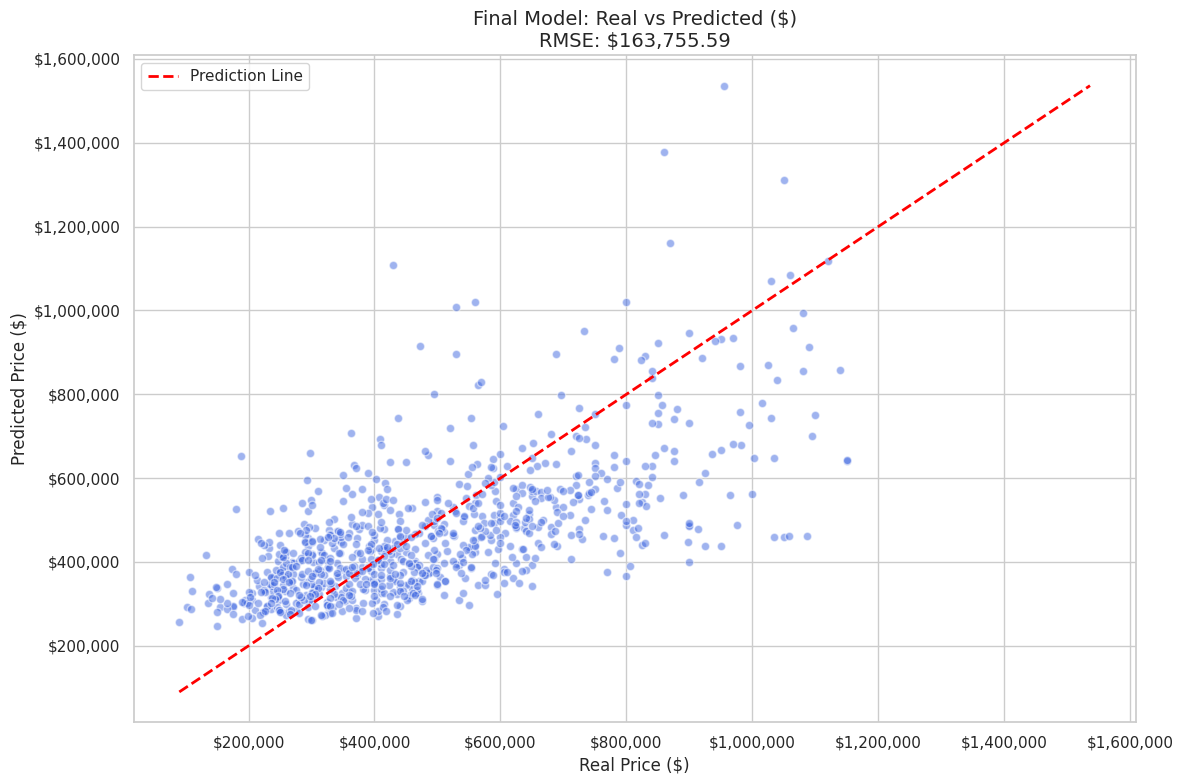

In [31]:
# plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# scatter plot
plt.scatter(y_test_real, y_pred_real, alpha=0.5, color='royalblue', edgecolors='w')

# linear regression line
max_val = max(y_test_real.max(), y_pred_real.max())
min_val = min(y_test_real.min(), y_pred_real.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Prediction Line')

plt.title(f'Final Model: Real vs Predicted ($)\nRMSE: ${rmse_final:,.2f}', fontsize=14)
plt.xlabel('Real Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.legend()

plt.ticklabel_format(style='plain', axis='both')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

The fact that our model got stuck in the $163k RMSE, makes us think that our model has reached the limit of what a simple Linear Regression can do with the provided data. In order to predict more accurate results we would need to provide more geographic data.

## **Task 2**

First, we begin by finding the median price to determine what is our breakpoint, to decide whether a house should be considered cheap or expensive in our model

In [32]:
# 1. Create the binary target variable
# We use the original cleaned dataset (with outliers) to get the true market median
median_price = df['price'].median()
print(f"Median House Price: ${median_price:,.2f}")

Median House Price: $465,000.00


In [33]:
# 1 if price > median, else 0
df['is_expensive'] = (df['price'] > median_price).astype(int)

Now that we have it, we can train our models

In [34]:
# 2. Split data into train and test sets
# we use the same features as linear model
X_logic = df[features]
y_logic = df['is_expensive']

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    X_logic, y_logic, test_size=0.2, random_state=42
)

In [35]:
# 3. Fit Logistic Regression model
# We increase max_iter to ensure convergence
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_log, y_train_log)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [36]:
# 4. Predict and compute accuracy
y_pred_log = log_reg.predict(X_test_log)
accuracy = accuracy_score(y_test_log, y_pred_log)

print(f"\nClassification Accuracy: {accuracy:.2%}")
print("\nClassification Report:")
print(classification_report(y_test_log, y_pred_log))


Classification Accuracy: 76.79%

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.79      0.77       449
           1       0.78      0.75      0.77       460

    accuracy                           0.77       909
   macro avg       0.77      0.77      0.77       909
weighted avg       0.77      0.77      0.77       909



When looking at the classification report, the precision tells us "of all the houses the model labeled as 'Expensive,' how many were actually expensive?", and as for the recall, "of all the truly expensive houses in the dataset, how many did the model actually find?".

Since the F1-score summarizes both of the aboved mentioned, we will focus mostly on this one. **Our score is 0.77 which is considered "ok", this meaning again, our model would need more information regarding location**

The support simply shows how many houses of each category were in our test set. It also helped us see if our data is imbalanced, which is not the case.

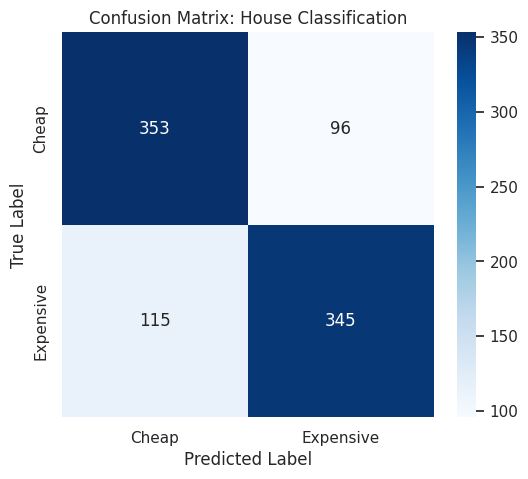

In [37]:
# 5. Visualize Confusion Matrix
# This helps see how many 'Cheap' houses were wrongly predicted as 'Expensive'
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test_log, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cheap', 'Expensive'],
            yticklabels=['Cheap', 'Expensive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: House Classification')
plt.show()

With the confusion matrix we can see our model is balanced, but of course still makes mistakes, most specifically by predicting expensive houses as if they were cheap, this is, one more time, a sign that location plays an important role here.

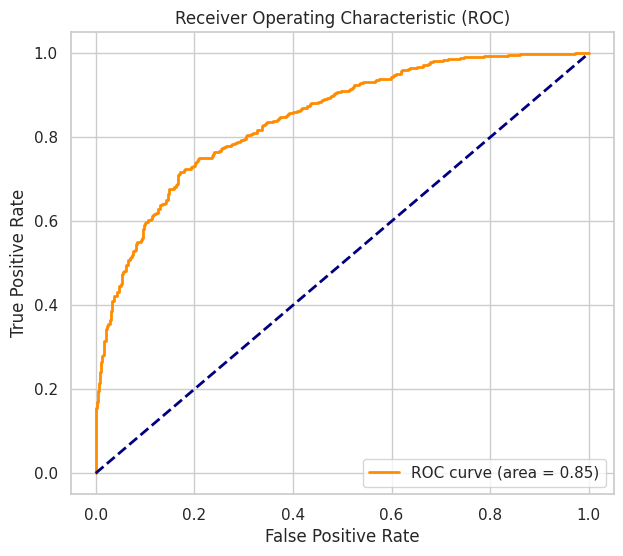

In [38]:
# 6. Visualize ROC Curve
# Logistic regression predicts probabilities, which we use to plot the ROC curve
y_probs = log_reg.predict_proba(X_test_log)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test_log, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

What we notice:

* The curve is located close to the "sweet spot" (top-left corner)
A perfect model would have a curve that goes straight up from (0,0) to (0,1) and then straight across to (1,1). It would find all expensive houses without ever making a false alarm.

* The dashed line represents a random classifier. The closer the ROC curve is to this line, the more guessing the model is doing.

* The AUC is a single number representing the total area under the ROC curve. It summarizes the overall quality of the model. In our case, the AUC is 0.85 which is an acceptable performance. Ideally, this should be the closest to 1.0

## **Task 3**

### Summary: Linear vs Logistic Regression

| | Linear Regression | Logistic Regression |
|---|---|---|
| **Task** | Predict a number | Predict a category |
| **Output** | Continuous (e.g. $450,000) | Binary (0=cheap, 1=expensive) |
| **Metric** | MSE / RMSE / R² | Accuracy / AUC / F1 |
| **Loss Function** | Mean Squared Error | Log Loss |
| **Visualization** | Scatter + regression line | Confusion matrix + ROC curve |


### Real-World Use Cases


**Linear Regression**
- Predicting exact house sale price
- Forecasting next month's rent
- Estimating renovation return on investment

**Logistic Regression**
- Is this house above market value? (yes/no)
- Will this customer default on a mortgage?
- Will this house sell within 30 days?

### Final reflection

Task 1 (RMSE): Our linear model reached a limit error because the market is not purely linear-location and house conditions create non-linear leaps in value

Task 2 (AUC 0.85): Our logistic model was much more successful because it focused on the decision boundary (median).